In [4]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para que los gráficos se vean modernos
sns.set_theme(style="whitegrid")

In [5]:
conn_str = (
    "Driver={SQL Server};"
    "Server=localhost\\SQLEXPRESS;" 
    "Database=Olist_Ecommerce;"
    "Trusted_Connection=yes;"
)

try:
    conn = pyodbc.connect(conn_str)
    print("¡Conexión exitosa! Ya podemos extraer datos.")
except Exception as e:
    print(f"Error de conexión: {e}")

¡Conexión exitosa! Ya podemos extraer datos.


In [6]:
# Celda 3 actualizada (sin el guion bajo al final de la tabla)
query = """
SELECT 
    DATEDIFF(day, o.order_estimated_delivery_date, o.order_delivered_customer_date) AS delay_days,
    CAST(r.review_score AS FLOAT) AS review_score
FROM dbo.orders o
JOIN dbo.order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered' 
  AND o.order_delivered_customer_date IS NOT NULL
"""

df = pd.read_sql(query, conn)
print(f"Dataset cargado: {len(df)} filas.")
df.head()

C:\Users\Andres\AppData\Local\Temp\ipykernel_15800\193183106.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Dataset cargado: 96353 filas.


,delay_days,review_score
0,-16,4.0
1,-5,5.0
2,-21,5.0
3,-20,5.0
4,-9,5.0


C:\Users\Andres\AppData\Local\Temp\ipykernel_15800\3466923724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='review_score', y='delay_days', data=df_filtered, palette='viridis')


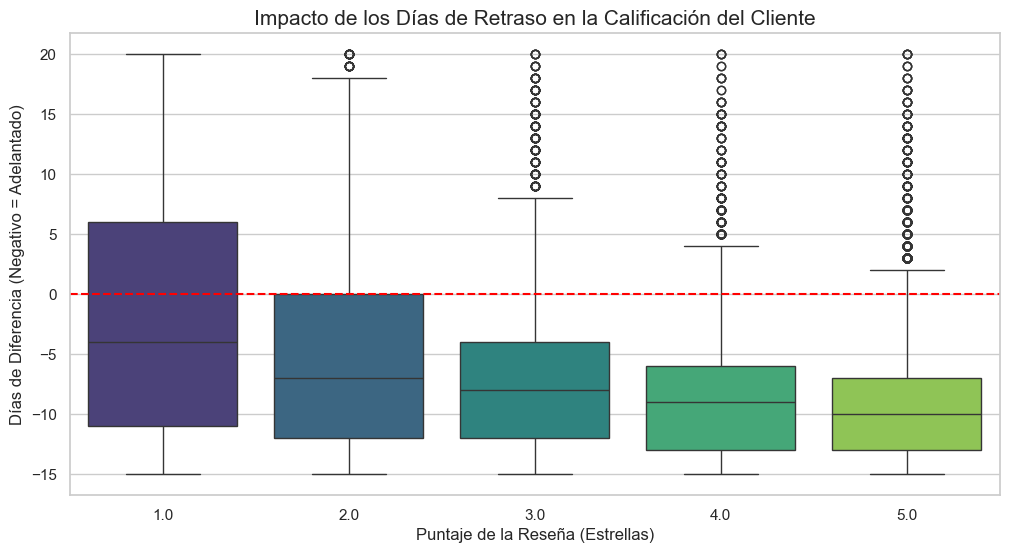

In [7]:
# Celda 4: Visualización del impacto de la logística
plt.figure(figsize=(12, 6))

# Vamos a filtrar para ver solo retrasos razonables (ej. de -10 a 20 días) 
# para que el gráfico no se deforme por valores extremos
df_filtered = df[(df['delay_days'] >= -15) & (df['delay_days'] <= 20)]

sns.boxplot(x='review_score', y='delay_days', data=df_filtered, palette='viridis')

plt.title('Impacto de los Días de Retraso en la Calificación del Cliente', fontsize=15)
plt.xlabel('Puntaje de la Reseña (Estrellas)', fontsize=12)
plt.ylabel('Días de Diferencia (Negativo = Adelantado)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', label='Fecha Prometida') # Línea de "promesa cumplida"

plt.show()

C:\Users\Andres\AppData\Local\Temp\ipykernel_15800\230332120.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cat = pd.read_sql(query_categorias_v2, conn)
C:\Users\Andres\AppData\Local\Temp\ipykernel_15800\230332120.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_delay', y='category', data=df_cat.head(10), palette='Reds_r')


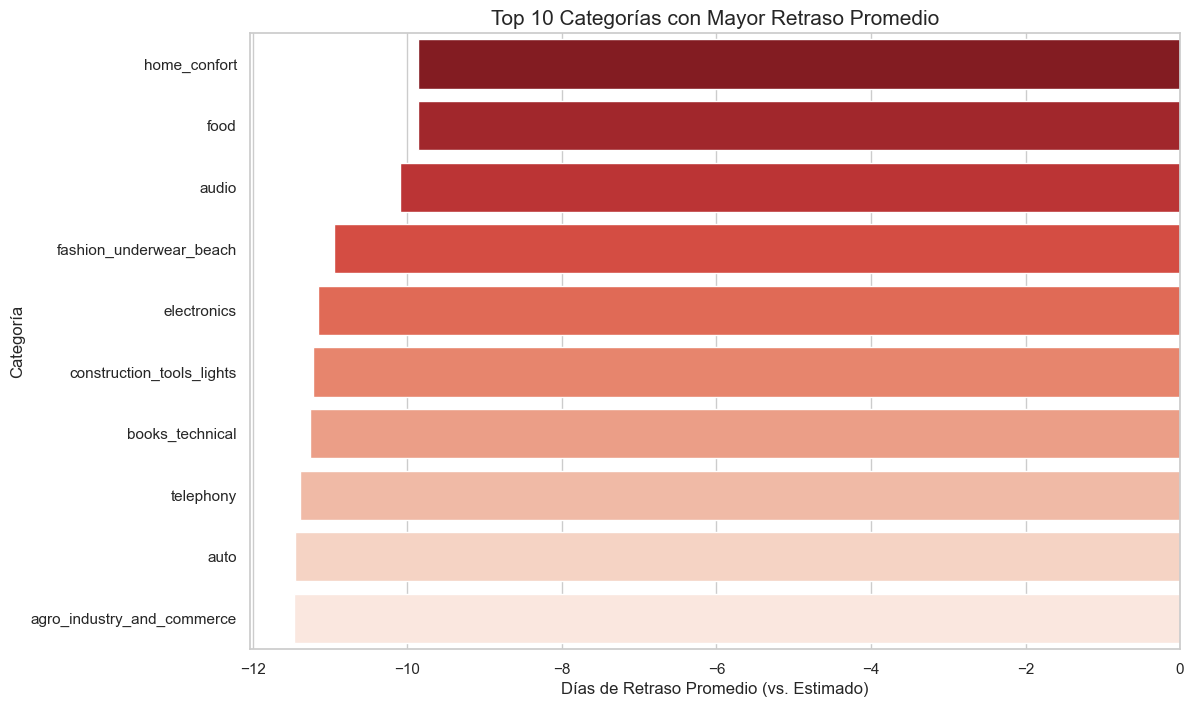

In [8]:
# Celda 5: Análisis por Categoría
query_categorias = """
SELECT 
    t.column2 AS category,
    AVG(DATEDIFF(day, o.order_estimated_delivery_date, o.order_delivered_customer_date)) AS avg_delay,
    AVG(CAST(r.review_score AS FLOAT)) AS avg_score,
    COUNT(o.order_id) AS total_orders
FROM dbo.orders o
JOIN dbo.order_reviews r ON o.order_id = r.order_id
JOIN dbo.products p ON o.order_id = p.product_id -- Nota: Ajustar si la relación es via order_items
JOIN dbo.product_category_name t ON p.product_category_name = t.column1
WHERE o.order_status = 'delivered' 
  AND t.column1 <> 'product_category_name'
GROUP BY t.column2
HAVING COUNT(o.order_id) > 100 -- Filtramos categorías con volumen representativo
ORDER BY avg_delay DESC
"""

# Nota: Si te da error el JOIN de products, es porque necesitamos pasar por order_items. 
# Usemos esta versión que es más segura:

query_categorias_v2 = """
SELECT 
    t.column2 AS category,
    AVG(CAST(DATEDIFF(day, o.order_estimated_delivery_date, o.order_delivered_customer_date) AS FLOAT)) AS avg_delay,
    AVG(CAST(r.review_score AS FLOAT)) AS avg_score,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM dbo.orders o
JOIN dbo.order_items oi ON o.order_id = oi.order_id
JOIN dbo.products p ON oi.product_id = p.product_id
JOIN dbo.order_reviews r ON o.order_id = r.order_id
JOIN dbo.product_category_name t ON p.product_category_name = t.column1
WHERE o.order_status = 'delivered' 
  AND t.column1 <> 'product_category_name'
GROUP BY t.column2
HAVING COUNT(DISTINCT o.order_id) > 100
ORDER BY avg_delay DESC
"""

df_cat = pd.read_sql(query_categorias_v2, conn)

# Visualizamos el Top 10 de categorías más problemáticas
plt.figure(figsize=(12, 8))
sns.barplot(x='avg_delay', y='category', data=df_cat.head(10), palette='Reds_r')
plt.title('Top 10 Categorías con Mayor Retraso Promedio', fontsize=15)
plt.xlabel('Días de Retraso Promedio (vs. Estimado)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.show()